# สัปดาห์ที่ 11: การจัดการข้อมูลขนาดใหญ่ด้วย GEEmap 🌍
## GE 234 Basic Programming for Geographers
**วันที่:** 16 มีนาคม 2569
**ผศ.ดร.สิทธิศักดิ์ หมูคำหล้า**

---

### สิ่งที่จะได้เรียนรู้วันนี้
1. Google Earth Engine (GEE) คืออะไร
2. การตั้งค่าและเชื่อมต่อ GEE
3. การใช้ geemap สำหรับ GEE ใน Python
4. การโหลดภาพดาวเทียม (Landsat, Sentinel-2)
5. การคำนวณดัชนีพืชพรรณ (NDVI)
6. การวิเคราะห์การเปลี่ยนแปลงเชิงเวลา
7. การ Export ข้อมูลจาก GEE

## 1. Google Earth Engine คืออะไร?

**Google Earth Engine (GEE)** เป็นแพลตฟอร์มประมวลผลข้อมูลเชิงภูมิศาสตร์บน Cloud ของ Google

### ข้อดีของ GEE
- ข้อมูลดาวเทียมฟรี มากกว่า 900+ dataset (Landsat, Sentinel, MODIS ฯลฯ)
- ประมวลผลบน Cloud ไม่ต้องดาวน์โหลดข้อมูลมาเครื่อง
- วิเคราะห์ข้อมูลย้อนหลังได้หลายสิบปี
- เหมาะกับงาน Remote Sensing, Land Use, Climate Change

### geemap คืออะไร?
**geemap** เป็น Python package ที่ทำให้ใช้งาน GEE ใน Python ได้สะดวก
สร้างโดย Prof. Qiongqiong Wu (ชื่อเดิม: Qiusheng Wu)

In [14]:
# ติดตั้ง geemap
!pip install geemap -q

## 2. การตั้งค่าและเชื่อมต่อ GEE

การใช้งาน GEE ครั้งแรก ต้อง authenticate กับ Google Account ก่อน

In [15]:
import ee
import geemap

# Authenticate (รันครั้งแรกครั้งเดียว - จะมี popup ให้ login)
ee.Authenticate()

# Initialize
try:
    ee.Initialize(project='ee-pythoncolab-418913')  # ใส่ Project ID ของตัวเอง
    print("✅ เชื่อมต่อ Google Earth Engine สำเร็จ!")
except Exception as e:
    print(f"⚠️ ยังไม่ได้เชื่อมต่อ: {e}")
    print("กรุณารัน ee.Authenticate() ก่อน")

✅ เชื่อมต่อ Google Earth Engine สำเร็จ!


## 3. สร้างแผนที่ด้วย geemap

geemap สร้างบน leafmap โดยเพิ่มความสามารถในการทำงานกับ GEE

In [16]:
# สร้างแผนที่ geemap
Map = geemap.Map(center=[13.75, 100.52], zoom=6)
Map

Map(center=[13.75, 100.52], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

## 4. การโหลดภาพดาวเทียม

### 4.1 Landsat 9
Landsat 9 เป็นดาวเทียมรุ่นล่าสุดของโครงการ Landsat (ความละเอียด 30 เมตร)

In [17]:
# โหลด Landsat 9 Surface Reflectance
# กรองตามพื้นที่ (กรุงเทพ) และช่วงเวลา
bangkok = ee.Geometry.Point([100.52, 13.75])

landsat9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
    .filterBounds(bangkok)
    .filterDate("2024-11-01", "2025-02-28")
    .filter(ee.Filter.lt("CLOUD_COVER", 20))  # เมฆน้อยกว่า 20%
    .sort("CLOUD_COVER")
)

print(f"จำนวนภาพที่พบ: {landsat9.size().getInfo()}")

# เลือกภาพแรก (เมฆน้อยที่สุด)
image = landsat9.first()
print(f"วันที่ถ่าย: {image.date().format('YYYY-MM-dd').getInfo()}")
print(f"เมฆ: {image.get('CLOUD_COVER').getInfo()}%")

จำนวนภาพที่พบ: 7
วันที่ถ่าย: 2025-01-07
เมฆ: 0.25%


In [18]:
# แสดงภาพ Landsat 9 แบบ True Color (RGB)
Map = geemap.Map(center=[13.75, 100.52], zoom=10)

# กำหนดค่า visualization
vis_true = {
    "bands": ["SR_B4", "SR_B3", "SR_B2"],  # Red, Green, Blue
    "min": 7000,
    "max": 20000
}

Map.addLayer(image, vis_true, "Landsat 9 True Color")
Map

Map(center=[13.75, 100.52], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

### 4.2 Sentinel-2
Sentinel-2 มีความละเอียดสูงกว่า (10 เมตร) เหมาะกับการวิเคราะห์ระดับเมือง

In [19]:
# โหลด Sentinel-2 Surface Reflectance
sentinel2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(bangkok)
    .filterDate("2024-11-01", "2025-02-28")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    .sort("CLOUDY_PIXEL_PERCENTAGE")
)

s2_image = sentinel2.first()
print(f"วันที่ถ่าย: {s2_image.date().format('YYYY-MM-dd').getInfo()}")

# แสดงภาพ Sentinel-2 True Color
vis_s2 = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000
}

Map = geemap.Map(center=[13.75, 100.52], zoom=11)
Map.addLayer(s2_image, vis_s2, "Sentinel-2 True Color")
Map

วันที่ถ่าย: 2025-01-15


Map(center=[13.75, 100.52], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

## 5. การคำนวณ NDVI (Normalized Difference Vegetation Index)

NDVI = (NIR - Red) / (NIR + Red)
ค่า NDVI อยู่ระหว่าง -1 ถึง 1:
- **> 0.5**: พืชพรรณหนาแน่น (ป่า)
- **0.2 - 0.5**: ทุ่งหญ้า, เกษตรกรรม
- **0 - 0.2**: ดิน, พื้นที่แห้งแล้ง
- **< 0**: น้ำ

In [20]:
# คำนวณ NDVI จาก Sentinel-2
# Band B8 = NIR, Band B4 = Red
ndvi = s2_image.normalizedDifference(["B8", "B4"]).rename("NDVI")

# แสดง NDVI บนแผนที่
vis_ndvi = {
    "min": -0.2,
    "max": 0.8,
    "palette": ["#d73027", "#fc8d59", "#fee08b", "#d9ef8b", "#91cf60", "#1a9850"]
}

Map = geemap.Map(center=[13.75, 100.52], zoom=11)
Map.addLayer(ndvi, vis_ndvi, "NDVI")
Map.add_colorbar(vis_ndvi, label="NDVI", position="bottomright")
Map

Map(center=[13.75, 100.52], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

## 6. การวิเคราะห์การเปลี่ยนแปลงเชิงเวลา (Time Series)

สามารถดึงค่า NDVI ย้อนหลังเป็น Time Series เพื่อดูแนวโน้มการเปลี่ยนแปลง

In [25]:
# คำนวณ NDVI เฉลี่ยรายเดือน ย้อนหลัง 1 ปี
def compute_monthly_ndvi(month):
    month = ee.Number(month)
    year = ee.Number(2024) # Assuming year is 2024
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    monthly_collection = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(bangkok)
        .filterDate(start, end)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )

    monthly_image = monthly_collection.median()

    has_bands = monthly_image.bandNames().containsAll(["B8", "B4"])

    ndvi = ee.Algorithms.If(
        has_bands,
        monthly_image.normalizedDifference(["B8", "B4"]).rename("NDVI"),
        ee.Image.constant(0).rename("NDVI").selfMask() # ภาพที่ไม่มีข้อมูล (masked) พร้อมแบนด์ 'NDVI'
    )

    # Cast to ee.Image and set properties, including system:time_start for charting
    return ee.Image(ndvi).set({"month": month, "system:time_start": start.millis()})

months = ee.List.sequence(1, 12)
monthly_ndvi = ee.ImageCollection(months.map(compute_monthly_ndvi))

print(f"จำนวนภาพรายเดือน: {monthly_ndvi.size().getInfo()}")

จำนวนภาพรายเดือน: 12


In [38]:
from geemap import chart # Explicitly import the chart submodule

# สร้าง Time Series Chart แบบสลับแกน
my_chart = chart.image_series(
    monthly_ndvi,
    region=roi_fc, # Use the FeatureCollection here
    reducer=ee.Reducer.mean(),
    scale=10,
    x_property="system:time_start", # ใช้เวลาดึงข้อมูลพื้นฐาน
    x_cols=["date"],               # สลับให้ "NDVI" ไปอยู่แกน X
    y_cols="NDVI",                 # สลับให้ "date" (เวลา) ไปอยู่แกน Y
    chart_type="LineChart"          # สามารถตั้งค่าเป็น "ScatterChart" หรือ "BarChart" ได้
)

my_chart

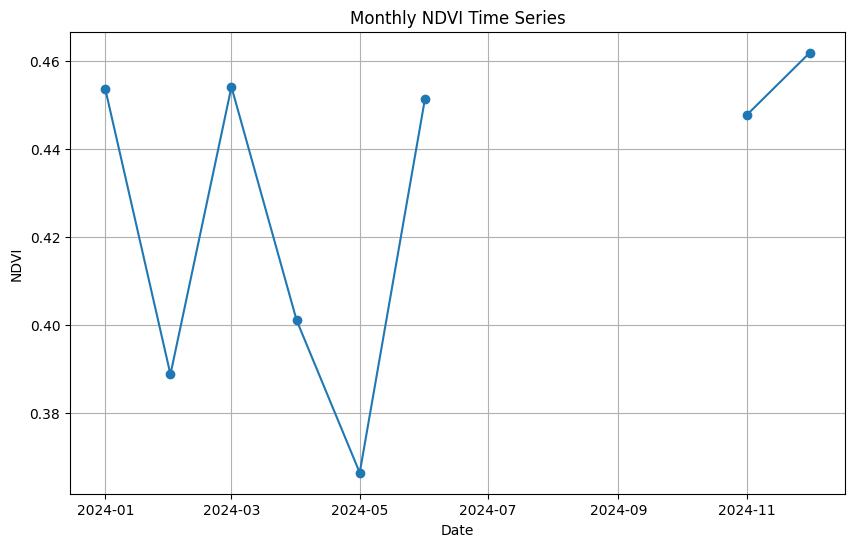

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. แปลง ImageCollection เป็น FeatureCollection ของค่าเฉลี่ย
def extract_mean(image):
    # คำนวณค่าเฉลี่ยในพื้นที่ ROI
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10,
        maxPixels=1e9
    )
    # คืนค่า Feature ที่มีค่า NDVI และเวลาในรูปแบบ property ปกติ ('millis')
    # geemap.ee_to_df จะดึง property ปกติมาเป็นคอลัมน์
    return ee.Feature(None, mean_dict).set('millis', image.get('system:time_start'))

# Map ฟังก์ชันไปบน ImageCollection และแปลงเป็น FeatureCollection อย่างชัดเจน
fc_ndvi = ee.FeatureCollection(monthly_ndvi.map(extract_mean))

# 2. แปลง FeatureCollection เป็น Pandas DataFrame
# ใช้ geemap.ee_to_df ซึ่งเป็นฟังก์ชันมาตรฐาน
df = geemap.ee_to_df(fc_ndvi)

# 3. จัดการข้อมูลเวลา (ใช้คอลัมน์ 'millis' ที่สร้างขึ้น)
df['datetime'] = pd.to_datetime(df['millis'], unit='ms')

# 4. สร้างกราฟด้วย Matplotlib (เวลา แกน X, NDVI แกน Y)
plt.figure(figsize=(10, 6))
plt.plot(df['datetime'], df['NDVI'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('Monthly NDVI Time Series')
plt.grid(True)
# ไม่ต้อง invert_yaxis แล้วเพราะเวลาอยู่แกน X ปกติ
plt.show()

## 7. การ Export ข้อมูลจาก GEE

สามารถ Export ภาพหรือข้อมูลจาก GEE ไปยัง Google Drive หรือดาวน์โหลดได้

In [42]:
# Export NDVI เป็น GeoTIFF ไปที่ Google Drive
# (จะสร้าง Task ใน GEE)
roi_export = ee.Geometry.Rectangle([100.3, 13.5, 100.8, 14.0])

task = ee.batch.Export.image.toDrive(
    image=ndvi,
    description="NDVI_Bangkok",
    folder="GEE_exports",
    region=roi_export,
    scale=10,
    crs="EPSG:4326",
    maxPixels=1e9
)

# task.start()  # เอา comment ออกเพื่อเริ่ม export จริง
print("📌 เอา comment ออกจาก task.start() แล้วรันอีกครั้งเพื่อ Export")
print("ไฟล์จะอยู่ใน Google Drive > GEE_exports")

📌 เอา comment ออกจาก task.start() แล้วรันอีกครั้งเพื่อ Export
ไฟล์จะอยู่ใน Google Drive > GEE_exports


In [ ]:
# ดาวน์โหลด NDVI เป็น GeoTIFF ลงเครื่อง (พื้นที่เล็ก)
# geemap.ee_export_image(
#     ndvi,
#     filename="ndvi_bangkok.tif",
#     scale=10,
#     region=roi_export
# )

## 8. ตัวอย่างเพิ่มเติม: แสดงภาพ Composite

สร้างภาพรวม (Composite) จากหลายภาพ เพื่อลดผลกระทบจากเมฆ

In [43]:
# สร้าง Median Composite ปี 2024 (ลดเมฆ)
composite_2024 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(ee.Geometry.Rectangle([100.3, 13.5, 100.8, 14.0]))
    .filterDate("2024-01-01", "2024-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .median()
)

Map = geemap.Map(center=[13.75, 100.52], zoom=11)
Map.addLayer(composite_2024, vis_s2, "Sentinel-2 Composite 2024")
Map

Map(center=[13.75, 100.52], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataG…

## 🏋️ แบบฝึกหัด

### แบบฝึกหัดที่ 1
เชื่อมต่อ GEE แล้วโหลดภาพ Sentinel-2 ของจังหวัดบ้านเกิดคุณ แสดงเป็น True Color

### แบบฝึกหัดที่ 2
คำนวณ NDVI ของพื้นที่ที่เลือก แสดงบนแผนที่พร้อม Colorbar

### แบบฝึกหัดที่ 3
เปรียบเทียบ NDVI ของ 2 ช่วงเวลา (เช่น ฤดูแล้ง vs ฤดูฝน) แสดงผลลัพธ์บนแผนที่

### แบบฝึกหัดที่ 4
สร้าง Median Composite ปี 2024 ของพื้นที่ที่คุณสนใจ แล้ว Export เป็น GeoTIFF

---
### 📌 สัปดาห์หน้า
**สัปดาห์ที่ 12:** การสร้างแผนที่ 3 มิติ ด้วย MapLibre

### 📋 งานที่ต้องส่ง
**Lab 4:** การประมวลผลข้อมูลด้วย NumPy และ GeoPandas

---
*ภาควิชาภูมิศาสตร์ คณะศิลปศาสตร์ มหาวิทยาลัยธรรมศาสตร์*

# Task
Extract the monthly NDVI time series data from the `monthly_ndvi` Earth Engine ImageCollection into a Pandas DataFrame, including the 'system:time_start' property. Then, prepare this data by converting 'system:time_start' to a datetime format. Finally, generate a custom scatter plot using Matplotlib with NDVI values on the x-axis and time on the y-axis, providing appropriate labels and a title to visualize the relationship between NDVI and time.

## Extract NDVI Time Series Data

### Subtask:
Convert the `monthly_ndvi` Earth Engine ImageCollection into a Pandas DataFrame, including the monthly NDVI values and their corresponding 'system:time_start' property.


**Reasoning**:
The subtask requires converting the `monthly_ndvi` Earth Engine ImageCollection into a Pandas DataFrame. This involves importing pandas and using the `geemap.image_collection_to_pandas()` function with specific parameters as outlined in the instructions.



In [30]:
import pandas as pd

# Convert the monthly_ndvi ImageCollection into a Pandas DataFrame
ndvi_df = geemap.image_collection_to_pandas(
    monthly_ndvi,
    bands=['NDVI'],
    region=roi,
    reducer=ee.Reducer.mean(),
    scale=10,
    x_property='system:time_start'
)

# Convert 'system:time_start' from milliseconds to datetime objects
ndvi_df['datetime'] = pd.to_datetime(ndvi_df['system:time_start'], unit='ms')

# Display the first few rows of the DataFrame
print("NDVI Time Series DataFrame:")
print(ndvi_df.head())


AttributeError: module 'geemap' has no attribute 'image_collection_to_pandas'